In [1]:
import pandas as pd

df = pd.read_csv('Housing.csv')

In [2]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [3]:
df.describe()


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [4]:
df.describe(include="all")

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545,545,545,545,545,545.000000,545,545
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN,2,3
top,NaN,NaN,NaN,NaN,NaN,yes,no,no,no,no,NaN,no,semi-furnished
freq,NaN,NaN,NaN,NaN,NaN,468,448,354,520,373,NaN,417,227
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,NaN,NaN,NaN,NaN,NaN,0.693578,NaN,NaN
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,NaN,NaN,NaN,NaN,NaN,0.861586,NaN,NaN
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


In [5]:
df.duplicated().sum()

np.int64(0)

## distribution of the target variable (price)


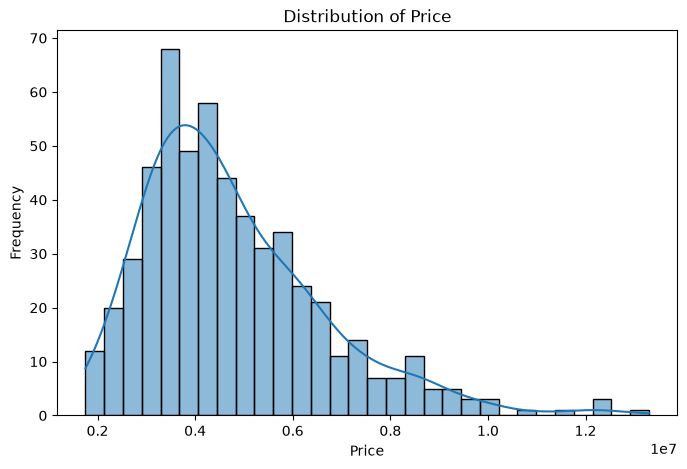

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()


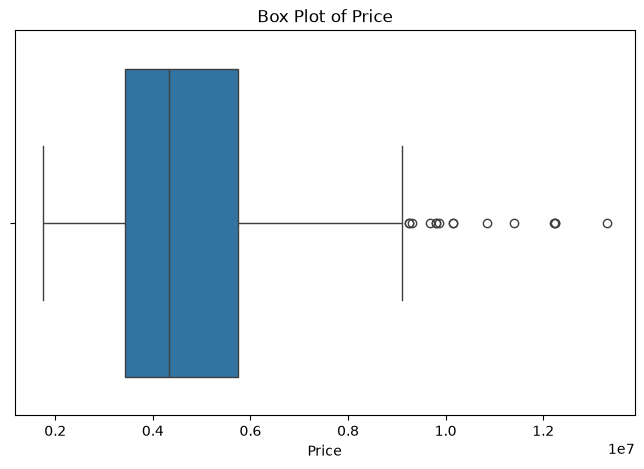

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["price"])

plt.title("Box Plot of Price")
plt.xlabel("Price")

plt.show()

In [8]:
df["price"].describe()


count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64

 # Feature selection discussion:

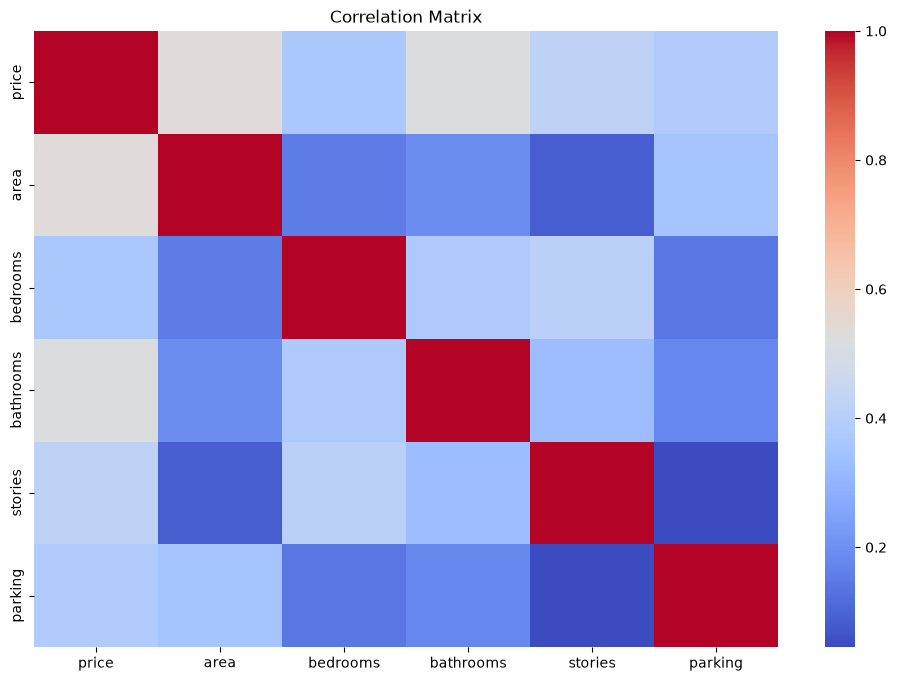

In [11]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [13]:
corr = df.corr(numeric_only=True)["price"]

top_features = corr.abs().sort_values(ascending=False).head(11)

print(top_features)

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64


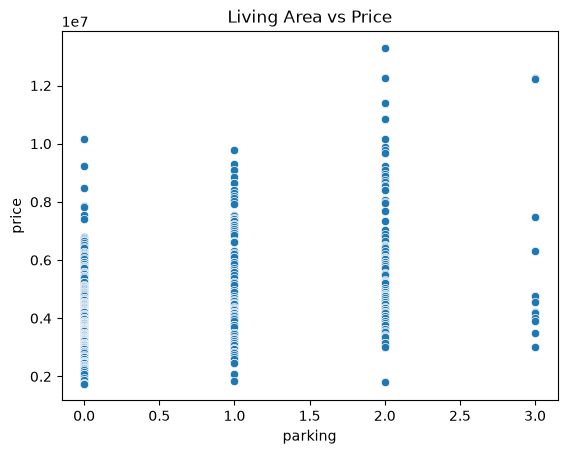

In [16]:
sns.scatterplot(
    x="parking",
    y="price",
    data=df
)

plt.title("Living Area vs Price")
plt.show()

## Reasoning for Feature Selection

Based on the exploratory data analysis , several features appear to be strong predictors of house prices.

- **Parking**  spaces appears to be a useful predictor of house prices. Homes with more parking spaces generally have higher selling prices because they offer greater convenience and are often associated with larger or more premium properties. This suggests a positive relationship between parking availability and house price, making it an important feature for the prediction model.

- **Bathrooms** are positively associated with house prices. Houses with more bathrooms tend to have higher selling prices because they provide greater convenience and are often found in larger homes.

- **Grade / Overall Quality** shows a strong positive correlation with price. Homes with better construction quality and finishes generally command higher market values.

- **Waterfront and View** also influence house prices significantly. Box plots indicate that waterfront properties and homes with better views have noticeably higher median prices than other houses.



Overall, these features demonstrate strong relationships with the target variable through correlation analysis and visualizations, making them suitable predictors for building a house price prediction model.

#  Handle missing values


In [18]:

df.isnull().sum()


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [19]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [20]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\ANKIT PANDEY\AppData\Local\Temp\ipykernel_1464\1664106601.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [21]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [22]:
df = pd.get_dummies(df, drop_first=True)

In [24]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    bool 
 13  f

### there are no missing values. I try to do without missing values.

# Correlation heatmap


In [26]:
corr = df.corr(numeric_only=True)

corr["price"].sort_values(ascending=False)

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
guestroom_yes                      0.255517
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64

In [27]:
corr["price"].sort_values(ascending=False)[1:6]

area                   0.535997
bathrooms              0.517545
airconditioning_yes    0.452954
stories                0.420712
parking                0.384394
Name: price, dtype: float64

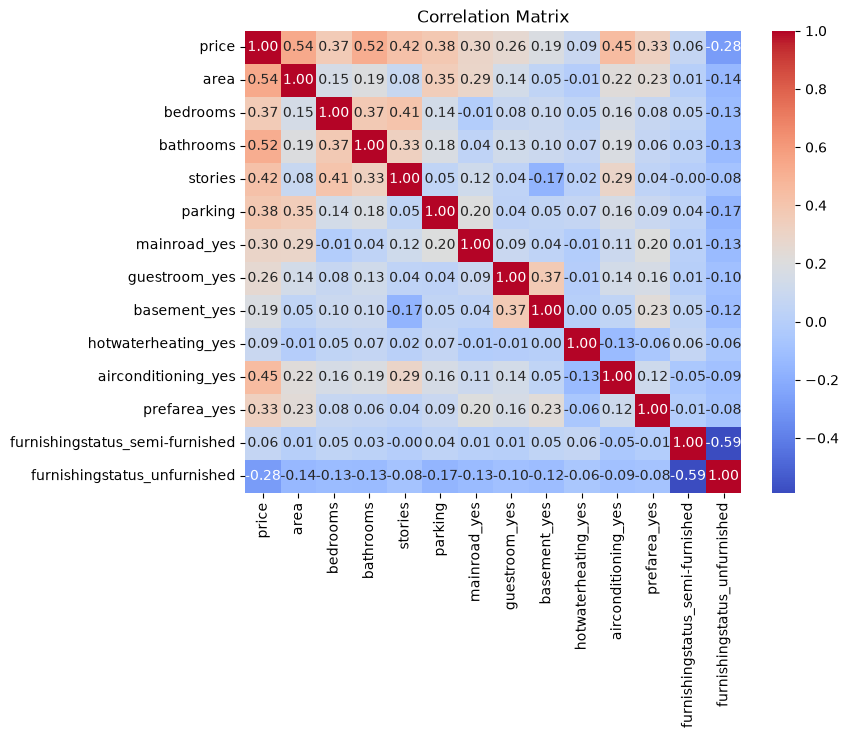

In [28]:


plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

# Train/test split


In [29]:
from sklearn.model_selection import train_test_split 

In [30]:
X = df.drop("price", axis=1)   # Features
y = df["price"]                # Target

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [32]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

Training Features: (436, 13)
Testing Features : (109, 13)
Training Target  : (436,)
Testing Target   : (109,)


# Train a Linear Regression model using scikit-learn



In [33]:
from sklearn.linear_model import LinearRegression

In [34]:
model = LinearRegression()

In [35]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 235.97, 76778.7 ,1094444.79,..., 629890.57,-126881.82,-413645.06]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['area','bedrooms','bathrooms',...,'prefarea_yes', 'furnishingstatus_semi-furnished','furnishingstatus_unfurnished']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.6e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


In [36]:
y_pred = model.predict(X_test)

In [39]:
prediction = pd.DataFrame({
    "Actual Price" : y_test,
    "Prediction" : y_pred
})

prediction.head(10)

,Actual Price,Prediction
316,4060000,5.164654e+06
77,6650000,7.224722e+06
360,3710000,3.109863e+06
90,6440000,4.612075e+06
493,2800000,3.294646e+06
209,4900000,3.532275e+06
176,5250000,5.611775e+06
249,4543000,6.368146e+06
516,2450000,2.722857e+06
426,3353000,2.629406e+06


# Evaluate model using

## Mean Squared Error(MSE)

In [41]:
from sklearn.metrics import mean_squared_error

# MSE: Average of the squared errors (units are squared, e.g., ₹²).

# Predict on test data
y_pred = model.predict(X_test)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")

Mean Squared Error (MSE): 1754318687330.66


## Root Mean Squared Error (RMSE)

In [42]:
from sklearn.metrics import mean_squared_error
import numpy as np

# RMSE: Square root of MSE (units are the same as the target variable, e.g., ₹),
# making it easier to understand and explain.

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 1324506.9600914388


## R² score


In [43]:
from sklearn.metrics import r2_score

# Calculate R² score
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)
#R² = 0.65 means the model explains 65% of the variation in house prices.

R² Score: 0.6529242642153184


C:\Users\ANKIT PANDEY\AppData\Local\Temp\ipykernel_1464\135187031.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


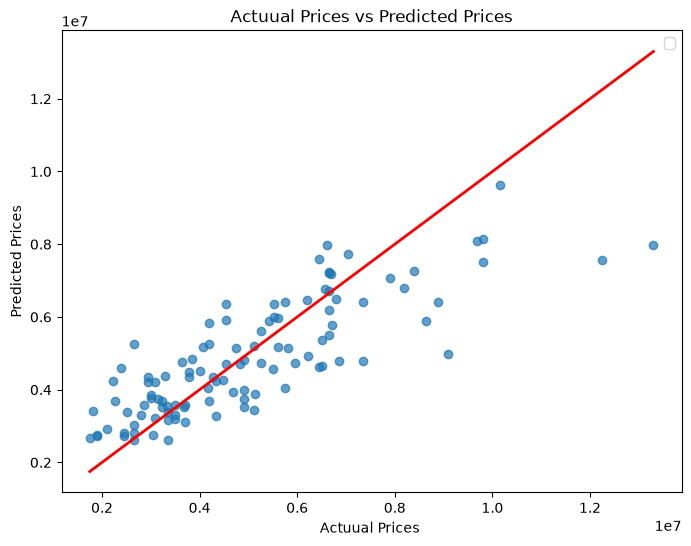

In [48]:
#Scatter plot: actual prices vs. predicted prices (the closer to a diagonal line, the better)

plt.figure(figsize=(8,6))

plt.scatter(y_test,y_pred,alpha=0.7)
plt.plot(
    [y_test.min() ,y_test.max()],
    [y_test.min() ,y_test.max()],
    color="red",
    linewidth = 2
)
plt.title("Actuual Prices vs Predicted Prices")
plt.xlabel("Actuual Prices ")
plt.ylabel("Predicted Prices")
plt.legend()

plt.show()


## Residual plot

In [49]:
# Residual = Actual Value − Predicted Value
residuals = y_test - y_pred

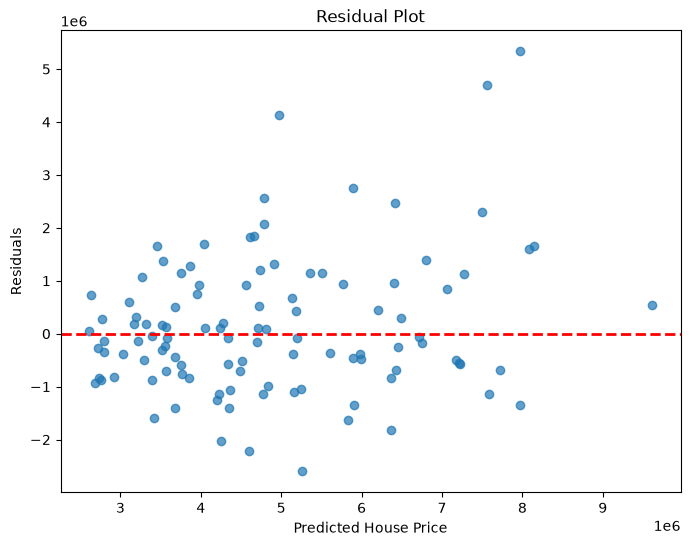

In [50]:
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)


plt.title("Residual Plot")
plt.xlabel("Predicted House Price")
plt.ylabel("Residuals")

plt.show()



## Coefficient analysis

In [51]:
# which features have the highest positive/negative impact on price?

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

coef_df

,Feature,Coefficient
0,area,2.359688e+02
1,bedrooms,7.677870e+04
2,bathrooms,1.094445e+06
3,stories,4.074766e+05
4,parking,2.248419e+05
5,mainroad_yes,3.679199e+05
6,guestroom_yes,2.316100e+05
7,basement_yes,3.902512e+05
8,hotwaterheating_yes,6.846499e+05
9,airconditioning_yes,7.914267e+05


In [52]:
coef_df = coef_df.sort_values(by="Coefficient", ascending=False)

coef_df

,Feature,Coefficient
2,bathrooms,1.094445e+06
9,airconditioning_yes,7.914267e+05
8,hotwaterheating_yes,6.846499e+05
10,prefarea_yes,6.298906e+05
3,stories,4.074766e+05
7,basement_yes,3.902512e+05
5,mainroad_yes,3.679199e+05
6,guestroom_yes,2.316100e+05
4,parking,2.248419e+05
1,bedrooms,7.677870e+04


## (Bonus) Compare Linear Regression against a Ridge or Lasso regularised model


In [53]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [54]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [55]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

In [56]:
lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

In [57]:
#  compare the models as instruction.

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred))
    ],
    "R² Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred)
    ]
})

comparison

,Model,RMSE,R² Score
0,Linear Regression,1.324507e+06,0.652924
1,Ridge,1.325320e+06,0.652498
2,Lasso,1.324508e+06,0.652924


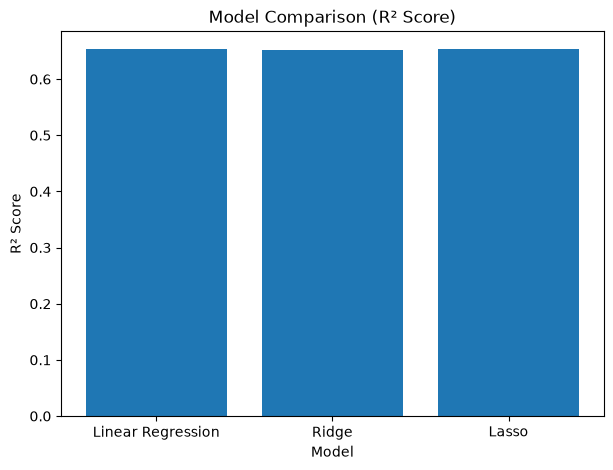

In [58]:
plt.figure(figsize=(7,5))

plt.bar(comparison["Model"], comparison["R² Score"])

plt.title("Model Comparison (R² Score)")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.show()